# Plotting Time Series Models

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [33]:
# set folder with data
path = '../results/'
# get all files in the folder
all_files = glob.glob(path + "*.csv")

In [34]:
# filter the files that contain "covid"
covid_files = [f for f in all_files if 'covid' in f]
# filter the files that contain "epidemics"
epidemics_files = [f for f in all_files if 'epidemics' in f]

In [35]:
# get the original data
df_covid = pd.read_csv('../Data/silver/covid_data_weekly.csv')  

In [36]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


In [37]:
nrow_dict = {}
for country in df_covid['country'].unique():
    df_temp = df_covid[df_covid['country'] == country]
    nrow_dict[country] = len(df_temp)

In [38]:
nrow_dict

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [39]:
from functools import reduce

# -------------------------------------------------------------------
# 1.  Load raw CSVs
# -------------------------------------------------------------------
df_dengue    = pd.read_csv('../Data/silver/dengue_no_split.csv')
df_zika      = pd.read_csv('../Data/silver/zika.csv').drop(columns=['Unnamed: 0'])
df_chic      = pd.read_csv('../Data/silver/chicunguya.csv').drop(columns=['Unnamed: 0'])
df_varicela  = pd.read_csv('../Data/silver/varicela.csv')

# -------------------------------------------------------------------
# 2.  Helper that:  (i) parses DATE  (ii) builds cumulative + t-1 series
# -------------------------------------------------------------------
def prep(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')

    # cumulative sum of new weekly cases
    df[f'cum_{prefix}'] = df['Casos'].cumsum()

    # keep only the useful columns
    return df[['DATE', f'cum_{prefix}']]

# -------------------------------------------------------------------
# 3.  Prepare each disease frame
# -------------------------------------------------------------------
dengue   = prep(df_dengue,   'dengue')
zika     = prep(df_zika,     'zika')
chik     = prep(df_chic,     'chik')
varicela = prep(df_varicela, 'var')

# -------------------------------------------------------------------
# 4.  Outer-merge on DATE → aligns differing timelines, fills gaps with NaN
# -------------------------------------------------------------------
df_epidemics = reduce(
    lambda left, right: pd.merge(left, right, on='DATE', how='outer'),
    [dengue, zika, chik, varicela]
).sort_values('DATE').set_index('DATE')
df_epidemics.reset_index(inplace=True)
df_epidemics.rename(columns={'DATE': 'date',
                             'cum_dengue':'dengue',
                             'cum_zika':'zika',
                             'cum_chik':'chik',
                             'cum_var': 'var'}, inplace=True)
df_epidemics


,date,dengue,zika,chik,var
0,2007-01-01,315,NaN,NaN,250.0
1,2007-01-08,551,NaN,NaN,557.0
2,2007-01-15,803,NaN,NaN,858.0
3,2007-01-22,1108,NaN,NaN,1124.0
4,2007-01-29,1468,NaN,NaN,1481.0
...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0
891,2023-12-04,666895,NaN,78140.0,1201709.0
892,2023-12-11,670341,76165.0,78141.0,1202139.0
893,2023-12-18,673653,76167.0,78143.0,1202483.0


# Wrangle

## Covid

In [40]:
df_covid.tail()

,country,date,new_cases,cases
1635,Uruguay,2023-02-06,555,1033265
1636,Uruguay,2023-02-13,501,1033766
1637,Uruguay,2023-02-20,280,1034046
1638,Uruguay,2023-02-27,257,1034303
1639,Uruguay,2023-03-06,0,1034303


In [41]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


In [42]:
dict_n_rows = {}
# count observations by country
for country in df_covid['country']:
    df_temp = df_covid[df_covid['country'] == country]
    dict_n_rows[country] = len(df_temp)

dict_n_rows

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [43]:
# ----------------------------------------------------------
# 1.  Make sure date is datetime & records are chronological
# ----------------------------------------------------------
df_covid['date'] = pd.to_datetime(df_covid['date'])
df_covid = df_covid.sort_values('date')

# ----------------------------------------------------------
# 2.  Pivot: rows = date, columns = country, values = cases
#     (all countries have the same number of observations)
# ----------------------------------------------------------
wide = (
    df_covid
      .pivot(index='date', columns='country', values='cases')
      .sort_index()                       # chronological index
)

# ----------------------------------------------------------
# 3.  Mark the first 80 % rows as TRAIN and the last 20 % as TEST
# ----------------------------------------------------------
split_point = int(len(wide) * 0.8)        # row where the 80/20 cut happens

wide['set'] = np.where(
    np.arange(len(wide)) < split_point,   # row-position test
    'train',
    'test'
)

# ----------------------------------------------------------
# 4.  (Optional) quick sanity check
# ----------------------------------------------------------
print(wide['set'].value_counts(normalize=True))
print(wide.head())


set
train    0.79878
test     0.20122
Name: proportion, dtype: float64
country     Brazil  Chile  Colombia  Dominican Republic  Germany  Italy  \
date                                                                      
2020-01-20       0      0         0                   0        0      0   
2020-01-27       0      0         0                   0       10      2   
2020-02-03       0      0         0                   0       14      3   
2020-02-10       0      0         0                   0       16      3   
2020-02-17       0      2         0                   0       16    155   

country     Mexico  Panama  US  Uruguay    set  
date                                            
2020-01-20       0       0   4        0  train  
2020-01-27       0       0   7        0  train  
2020-02-03       0       0  11        0  train  
2020-02-10       0       0  13        0  train  
2020-02-17       0       0  15        0  train  


In [44]:
wide.tail()

country,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
date,,,,,,,,,,,
2023-02-06,36932830,5138732,6355637,660412,37907312,25519067,7400848,1030214,102862878,1033265,test
2023-02-13,36987682,5149301,6356468,660492,38002114,25547414,7429778,1030658,103136076,1033766,test
2023-02-20,37020531,5163316,6357173,660533,38111063,25576852,7450992,1031014,103382762,1034046,test
2023-02-27,37081209,5180329,6358232,660705,38210851,25603510,7470653,1031273,103646974,1034303,test
2023-03-06,37076053,5192286,6359093,660790,38249060,25603510,7483444,1031731,103802701,1034303,test


In [45]:
df_covid_w = wide.copy().reset_index()

## Epidemics

In [46]:
# For each column in df_epidemics except 'date', create a new train/test split column.
# If the column contains NaNs, only the non-NaN entries are split by 80/20.
# The new column will be named "<original_column>_split".

for col in df_epidemics.columns:
    if col == 'date':
        continue
    series = df_epidemics[col]
    non_na = series.dropna()
    n = len(non_na)
    split_i = int(n * 0.8)
    split_labels = ['train'] * split_i + ['test'] * (n - split_i)
    
    # Initialize new split column with NaNs
    split_col = [np.nan] * len(series)
    
    # Get the indices of non-na values in order
    non_na_indices = non_na.index.tolist()
    for pos, row_idx in enumerate(non_na_indices):
        split_col[row_idx] = split_labels[pos]
    
    df_epidemics[col + '_split'] = split_col

df_epidemics

,date,dengue,zika,chik,var,dengue_split,zika_split,chik_split,var_split
0,2007-01-01,315,NaN,NaN,250.0,train,NaN,NaN,train
1,2007-01-08,551,NaN,NaN,557.0,train,NaN,NaN,train
2,2007-01-15,803,NaN,NaN,858.0,train,NaN,NaN,train
3,2007-01-22,1108,NaN,NaN,1124.0,train,NaN,NaN,train
4,2007-01-29,1468,NaN,NaN,1481.0,train,NaN,NaN,train
...,...,...,...,...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0,test,NaN,test,test
891,2023-12-04,666895,NaN,78140.0,1201709.0,test,NaN,test,test
892,2023-12-11,670341,76165.0,78141.0,1202139.0,test,test,test,test
893,2023-12-18,673653,76167.0,78143.0,1202483.0,test,test,test,test


# Plots

## Covid

In [47]:
df_covid_w.head()

country,date,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
0,2020-01-20,0,0,0,0,0,0,0,0,4,0,train
1,2020-01-27,0,0,0,0,10,2,0,0,7,0,train
2,2020-02-03,0,0,0,0,14,3,0,0,11,0,train
3,2020-02-10,0,0,0,0,16,3,0,0,13,0,train
4,2020-02-17,0,2,0,0,16,155,0,0,15,0,train


In [48]:
len(df_covid_w)

164

In [49]:
covid_files

['../results\\ARIMA_covid.csv',
 '../results\\BM_covid.csv',
 '../results\\ElasticNet_covid.csv',
 '../results\\GB_covid.csv',
 '../results\\GGM-Arima_covid.csv',
 '../results\\GGM_Arima_covid.csv',
 '../results\\GGM_covid.csv',
 '../results\\Lasso_covid.csv',
 '../results\\OLS_covid.csv',
 '../results\\PROPHET_covid.csv',
 '../results\\RF_covid.csv',
 '../results\\Ridge_covid.csv',
 '../results\\RNN_covid.csv',
 '../results\\SEIR_covid.csv',
 '../results\\SIR_covid.csv',
 '../results\\SVM_covid.csv']

In [50]:
# files you want to exclude
drop_these = {
    '../results\\OLS_covid.csv',
    '../results\\Lasso_covid.csv',
    '../results\\Ridge_covid.csv',
    '../results\\RidgeCV_covid.csv',
    '../results\\ElasticNet_covid.csv',
    '../results\\SVM_covid.csv',
    '../results\\GB_covid.csv',
    '../results\\RF_covid.csv'
}

# keep everything that is *not* in drop_these
covid_files_ts = [f for f in covid_files if f not in drop_these]

print(covid_files_ts)


['../results\\ARIMA_covid.csv', '../results\\BM_covid.csv', '../results\\GGM-Arima_covid.csv', '../results\\GGM_Arima_covid.csv', '../results\\GGM_covid.csv', '../results\\PROPHET_covid.csv', '../results\\RNN_covid.csv', '../results\\SEIR_covid.csv', '../results\\SIR_covid.csv']


In [51]:
covid_files_ts

['../results\\ARIMA_covid.csv',
 '../results\\BM_covid.csv',
 '../results\\GGM-Arima_covid.csv',
 '../results\\GGM_Arima_covid.csv',
 '../results\\GGM_covid.csv',
 '../results\\PROPHET_covid.csv',
 '../results\\RNN_covid.csv',
 '../results\\SEIR_covid.csv',
 '../results\\SIR_covid.csv']

### Colombia

In [52]:
df_col = df_covid_w[['date', 'Colombia', 'set']].copy()
df_col

country,date,Colombia,set
0,2020-01-20,0,train
1,2020-01-27,0,train
2,2020-02-03,0,train
3,2020-02-10,0,train
4,2020-02-17,0,train
...,...,...,...
159,2023-02-06,6355637,test
160,2023-02-13,6356468,test
161,2023-02-20,6357173,test
162,2023-02-27,6358232,test


In [53]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in covid_files_ts:
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp_col = df_temp[['Colombia']]
    df_temp_col = df_temp_col.rename(columns={'Colombia': model})  # rename the column to the model name
    df_col = pd.concat([df_col, df_temp_col], axis=1)
    

In [54]:
df_col.rename(columns={'Colombia':'cases'}, inplace=True)  # rename the column to cases

In [55]:
df_col

,date,cases,set,arima,bm,ggm-arima,ggm,ggm,prophet,rnn,seir,sir
0,2020-01-20,0,train,4.555860e+01,6.443372e+03,1.098966e+02,1.098966e+02,1.729331e+03,-8.054501e+04,NaN,0.0,0.0
1,2020-01-27,0,train,1.093898e+04,1.328381e+04,9.177850e+02,9.177850e+02,4.954847e+03,-6.030733e+03,NaN,0.0,0.0
2,2020-02-03,0,train,1.838541e+03,2.054481e+04,1.211721e+03,1.211721e+03,9.224458e+03,2.048836e+04,NaN,0.0,0.0
3,2020-02-10,0,train,3.980353e+03,2.825115e+04,1.053257e+03,1.053257e+03,1.439753e+04,2.157715e+04,NaN,0.0,0.0
4,2020-02-17,0,train,3.107122e+03,3.642891e+04,1.403096e+03,1.403096e+03,2.040593e+04,1.745287e+04,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
159,2023-02-06,6355637,test,7.459096e+06,6.250795e+06,6.703556e+06,6.703556e+06,6.708336e+06,7.447023e+06,3622974.75,10180411.0,5481699.0
160,2023-02-13,6356468,test,7.504647e+06,6.251953e+06,6.716586e+06,6.716586e+06,6.720171e+06,7.477474e+06,3622571.50,10182022.0,5481699.0
161,2023-02-20,6357173,test,7.550199e+06,6.253041e+06,6.729537e+06,6.729537e+06,6.731859e+06,7.506851e+06,3622249.25,10183446.0,5481699.0
162,2023-02-27,6358232,test,7.595753e+06,6.254065e+06,6.742323e+06,6.742323e+06,6.743404e+06,7.533388e+06,3621993.00,10184705.0,5481699.0


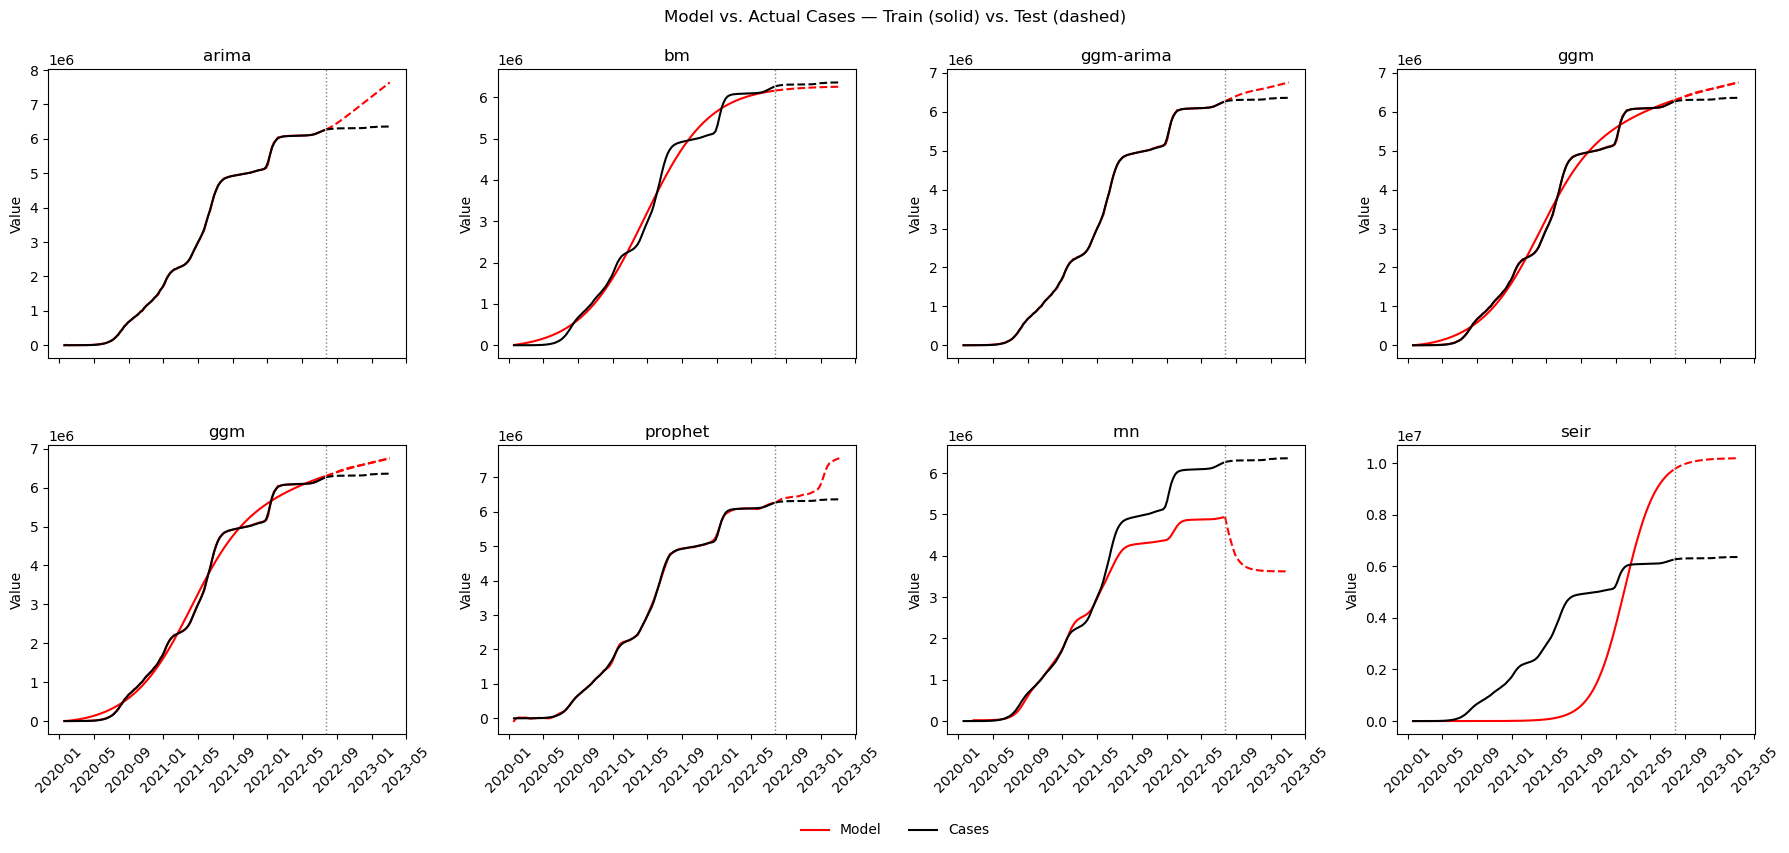

In [56]:
# ------------------------------------------------------------------
# 1.  Split into train / test & choose the 8 model columns
# ------------------------------------------------------------------
y_cols   = df_col.columns[3:]                     # 8 model columns
train_df = df_col[df_col['set'] == 'train']
test_df  = df_col[df_col['set'] == 'test']

split_date = test_df['date'].min()               # first test date → vertical line

# ------------------------------------------------------------------
# 2.  2 × 4 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # --------------------------------------------------------------
    # Model predictions : red
    # --------------------------------------------------------------
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # --------------------------------------------------------------
    # Actual cases       : black
    # --------------------------------------------------------------
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['cases'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['cases'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3.  Shared legend (labels defined only in first subplot)
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])   # leave space below for legend
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03)
plt.subplots_adjust(hspace=0.3)  # space between rows
plt.show()


## Epidemics

In [57]:
epidemics_files

['../results\\ARIMA_epidemics.csv',
 '../results\\BM_epidemics.csv',
 '../results\\ElasticNet_epidemics.csv',
 '../results\\GB_epidemics.csv',
 '../results\\GGM-ARIMA_epidemics.csv',
 '../results\\GGM_epidemics.csv',
 '../results\\Lasso_epidemics.csv',
 '../results\\OLS_epidemics.csv',
 '../results\\PROPHET_epidemics.csv',
 '../results\\RF_epidemics.csv',
 '../results\\Ridge_epidemics.csv',
 '../results\\RNN_epidemics.csv',
 '../results\\SEIR_epidemics.csv',
 '../results\\SIR_epidemics.csv',
 '../results\\SVM_epidemics.csv']

In [58]:
# files you want to exclude
drop_these = {
    '../results\\OLS_epidemics.csv',
    '../results\\Lasso_epidemics.csv',
    '../results\\Ridge_epidemics.csv',
    '../results\\RidgeCV_epidemics.csv',
    '../results\\ElasticNet_epidemics.csv',
    '../results\\SVM_epidemics.csv',
    '../results\\GB_epidemics.csv',
    '../results\\RF_epidemics.csv'
}

# keep everything that is *not* in drop_these
epidemics_files_ts = [f for f in epidemics_files if f not in drop_these]

epidemics_files_ts

['../results\\ARIMA_epidemics.csv',
 '../results\\BM_epidemics.csv',
 '../results\\GGM-ARIMA_epidemics.csv',
 '../results\\GGM_epidemics.csv',
 '../results\\PROPHET_epidemics.csv',
 '../results\\RNN_epidemics.csv',
 '../results\\SEIR_epidemics.csv',
 '../results\\SIR_epidemics.csv']

### Dengue

In [59]:
df_dengue = df_epidemics[['date', 'dengue', 'dengue_split']].copy()
df_dengue.rename(columns={'dengue_split': 'set'}, inplace=True)
df_dengue

,date,dengue,set
0,2007-01-01,315,train
1,2007-01-08,551,train
2,2007-01-15,803,train
3,2007-01-22,1108,train
4,2007-01-29,1468,train
...,...,...,...
890,2023-11-27,663526,test
891,2023-12-04,666895,test
892,2023-12-11,670341,test
893,2023-12-18,673653,test


In [60]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in epidemics_files_ts:
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp_d = df_temp.iloc[:, :2]  # get only the first two columns
    df_temp_d.columns = ['date', model]
    print(df_temp_d.head())
    #df_dengue = pd.concat([df_col, df_temp_d], axis=1)

        date        arima
0   1/1/2007   314.859128
1   1/8/2007   550.894905
2  1/15/2007   787.258660
3  1/22/2007  1055.390161
4  1/29/2007  1411.422632
         date           bm
0  2007-01-01   302.977332
1  2007-01-08   607.161057
2  2007-01-15   912.554537
3  2007-01-22  1219.161131
4  2007-01-29  1526.984194
         date    ggm-arima
0  2008-04-24  2189.396372
1  2008-05-01  2240.222099
2  2008-05-08  2306.138166
3  2008-05-15  2384.313260
4  2008-05-22  2473.118503
         date         ggm
0  2007-01-01   27.953391
1  2007-01-08   79.136904
2  2007-01-15  145.516986
3  2007-01-22  224.242392
4  2007-01-29  313.672778
        date     prophet
0   1/1/2007 -999.492237
1   1/8/2007 -615.110023
2  1/15/2007 -201.506938
3  1/22/2007  278.682162
4  1/29/2007  805.598525
         date  rnn
0  2007-01-01  NaN
1  2007-01-08  NaN
2  2007-01-15  NaN
3  2007-01-22  NaN
4  2007-01-29  NaN
         date         seir
0  2007-01-01   945.000000
1  2007-01-08  1624.050590
2  2007-01-15  1997

In [61]:
df_dengue.head()


,date,dengue,set
0,2007-01-01,315,train
1,2007-01-08,551,train
2,2007-01-15,803,train
3,2007-01-22,1108,train
4,2007-01-29,1468,train
